In [3]:
returns = pd.read_csv(
    "../data/processed/nav_with_returns.csv"
)

transactions = pd.read_csv(
    "../data/processed/08_investor_transactions_cleaned.csv"
)

scheme_perf = pd.read_csv(
    "../data/processed/07_scheme_performance_cleaned.csv"
)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import numpy as np

var_results = []

for fund in returns["amfi_code"].unique():

    fund_returns = returns[
        returns["amfi_code"] == fund
    ]["daily_return"].dropna()

    var95 = np.percentile(
        fund_returns,
        5
    )

    var_results.append(
        [fund, var95]
    )

var_df = pd.DataFrame(
    var_results,
    columns=[
        "amfi_code",
        "VaR_95"
    ]
)

var_df.head()

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


In [5]:
var_df.to_csv(
    "../data/processed/var_results.csv",
    index=False
)

## Insight 1

VaR estimates the maximum expected daily loss at a 95% confidence level. Funds with higher negative VaR values carry greater downside risk.

In [6]:
transactions = pd.read_csv(
    "../data/processed/08_investor_transactions_cleaned.csv"
)

cohort = transactions.groupby(
    ["age_group", "transaction_type"]
)["amount_inr"].sum().reset_index()

cohort.head()

,age_group,transaction_type,amount_inr
0,18-25,Lumpsum,307670734
1,18-25,Redemption,191668045
2,18-25,Sip,32300613
3,26-35,Lumpsum,862283467
4,26-35,Redemption,500729411


In [ ]:
cohort.to_csv(
    "../data/processed/cohort_analysis.csv",
    index=False
)

<Axes: xlabel='transaction_type', ylabel='age_group'>

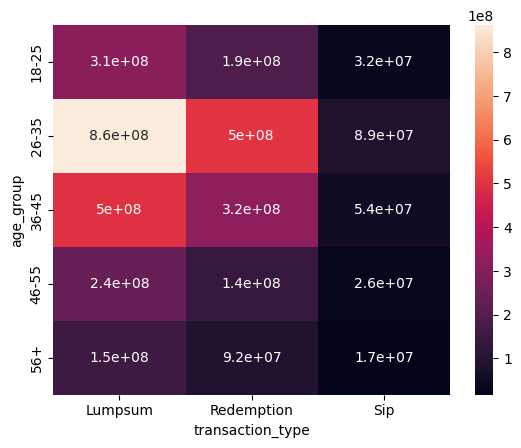

In [7]:
sns.heatmap(
    cohort.pivot(
        index="age_group",
        columns="transaction_type",
        values="amount_inr"
    ),
    annot=True
)

In [16]:
plt.savefig(
    "../reports/cohort_analysis_heatmap.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

# Investor Cohort Analysis

In [10]:
scheme_perf.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [11]:
def recommend_fund(risk):

    if risk == "Low":
        return scheme_perf[
            scheme_perf["risk_grade"] == "Low"
        ].nlargest(
            5,
            "return_3yr_pct"
        )

    elif risk == "Moderate":
        return scheme_perf[
            scheme_perf["risk_grade"] == "Moderate"
        ].nlargest(
            5,
            "return_3yr_pct"
        )

    else:
        return scheme_perf[
            scheme_perf["risk_grade"] == "Very High"
        ].nlargest(
            5,
            "return_3yr_pct"
        )

In [12]:
recommend_fund("Moderate")

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,0.97,1.06,1.70,14.0,-17.41,6434,1.55,5,Moderate
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,0.96,1.06,1.66,14.0,-17.07,11361,1.46,5,Moderate
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,14.12,14.41,13.02,13.53,0.88,1.03,1.03,1.27,14.0,-26.59,41553,0.80,3,Moderate
15,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Large Cap,Regular,15.84,14.00,14.70,13.14,0.86,0.88,1.00,1.68,14.0,-16.07,20909,1.51,4,Moderate
28,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Large Cap,Regular,14.82,13.78,12.86,12.44,1.34,1.03,0.98,1.25,14.0,-15.07,23500,1.60,5,Moderate


# Fund Recommendation Engine

In [13]:
recommend_fund("Low")
recommend_fund("Moderate")
recommend_fund("Very High")


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,0.97,0.90,1.47,25.0,-23.61,41613,1.53,5,Very High
27,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Small Cap,Regular,21.97,20.98,22.62,20.47,0.51,1.00,0.84,1.40,25.0,-14.45,21545,1.38,4,Very High
17,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Small Cap,Regular,21.30,20.15,21.88,19.35,0.80,1.03,0.81,1.14,25.0,-30.87,43630,1.53,4,Very High


## Insight 3
The recommender system suggests funds based on investor risk appetite and historical performance metrics.


In [3]:
var_df.to_csv(
    "../data/processed/var_results.csv",
    index=False
)

NameError: name 'var_df' is not defined

In [ ]:
import pandas as pd

investors = pd.read_csv(
    "../data/processed/08_investor_transactions_cleaned.csv"
)

holdings = pd.read_csv(
    "../data/processed/09_portfolio_holdings_cleaned.csv"
)

print("Investor Columns")
print(investors.columns.tolist())

print("\nHoldings Columns")
print(holdings.columns.tolist())

Investor Columns
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

Holdings Columns
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [ ]:
import pandas as pd

nav = pd.read_csv(
    "../data/processed/nav_with_returns.csv"
)

print(nav.columns.tolist())

['amfi_code', 'date', 'nav', 'daily_return']


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
nav = pd.read_csv("../data/processed/nav_with_returns.csv")
investors = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")
holdings = pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])
investors["transaction_date"] = pd.to_datetime(investors["transaction_date"])

print("Data Loaded Successfully")

Data Loaded Successfully


## Data Loading and Preparation

Load the processed datasets required for advanced analytics:
- NAV history with daily returns
- Investor transactions
- Portfolio holdings

Convert date columns into datetime format for time-series analysis.

In [7]:
results = []

for fund in nav["amfi_code"].unique():

    returns = nav.loc[
        nav["amfi_code"] == fund,
        "daily_return"
    ].dropna()

    if len(returns) > 20:

        var95 = np.percentile(returns, 5)

        cvar95 = returns[
            returns <= var95
        ].mean()

        results.append([
            fund,
            round(var95, 6),
            round(cvar95, 6)
        ])

var_cvar_report = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar_report.to_csv(
    "var_cvar_report.csv",
    index=False
)

var_cvar_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


## Historical Value at Risk (VaR) and Conditional VaR (CVaR)

This section calculates downside risk metrics for each mutual fund scheme.

- VaR (95%) measures the maximum expected loss under normal market conditions.
- CVaR measures the average loss beyond the VaR threshold.

The results are exported to `var_cvar_report.csv`.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

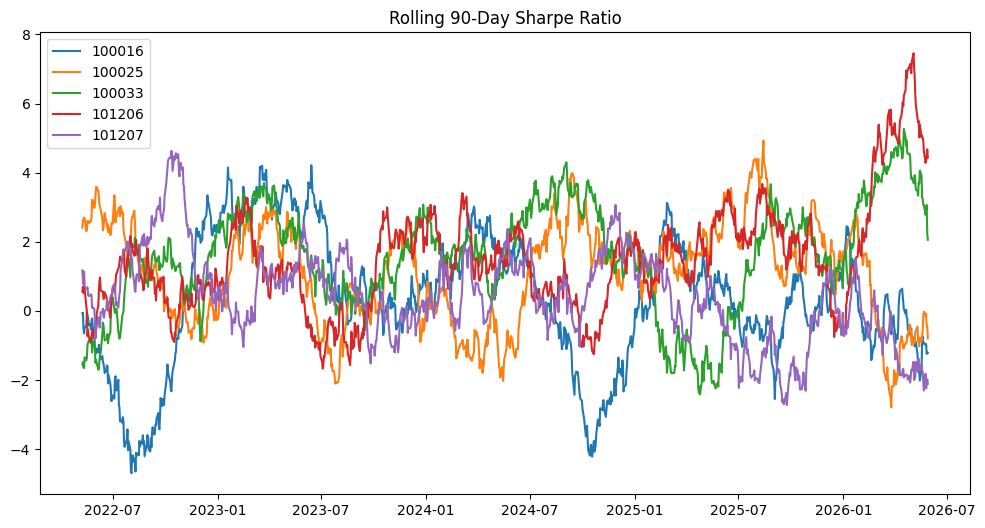

In [8]:
plt.figure(figsize=(12,6))

top_funds = (
    nav.groupby("amfi_code")
       .size()
       .sort_values(ascending=False)
       .head(5)
       .index
)

for fund in top_funds:

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    temp["rolling_sharpe"] = (
        temp["daily_return"]
        .rolling(90)
        .mean()
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.legend()

plt.savefig(
    "rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Rolling 90-Day Sharpe Ratio Analysis

The Sharpe Ratio evaluates risk-adjusted returns.

This analysis:
- Computes rolling 90-day Sharpe ratios
- Tracks performance consistency over time
- Visualizes trends for key mutual fund schemes

The chart is exported as `rolling_sharpe_chart.png`.

In [9]:
investors["cohort_year"] = (
    investors.groupby("investor_id")
    ["transaction_date"]
    .transform("min")
    .dt.year
)

cohort_analysis = (
    investors.groupby("cohort_year")
    .agg(
        avg_sip_amount=("amount_inr","mean"),
        total_invested=("amount_inr","sum")
    )
)

cohort_analysis

,avg_sip_amount,total_invested
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


## Investor Cohort Analysis

Investors are grouped based on their first transaction year.

This analysis helps identify:
- Average investment amount by cohort
- Total investment contribution
- Long-term investor behavior patterns

In [10]:
sip = investors[
    investors["transaction_type"]
    .str.upper()
    == "SIP"
].copy()

sip = sip.sort_values(
    ["investor_id","transaction_date"]
)

risk_list = []

for investor, grp in sip.groupby("investor_id"):

    if len(grp) >= 6:

        avg_gap = (
            grp["transaction_date"]
            .diff()
            .dt.days
            .mean()
        )

        status = (
            "At Risk"
            if avg_gap > 35
            else "Healthy"
        )

        risk_list.append(
            [investor, avg_gap, status]
        )

sip_continuity = pd.DataFrame(
    risk_list,
    columns=[
        "investor_id",
        "avg_gap_days",
        "status"
    ]
)

sip_continuity.head()

,investor_id,avg_gap_days,status
0,INV000004,85.400000,At Risk
1,INV000008,70.400000,At Risk
2,INV000010,64.800000,At Risk
3,INV000011,40.166667,At Risk
4,INV000012,57.000000,At Risk


## SIP Continuity Analysis

This section evaluates the consistency of SIP investments.

Objectives:
- Calculate average gap between SIP transactions
- Identify irregular investment behavior
- Flag investors with gaps greater than 35 days as "At Risk"

In [11]:
fund_stats = (
    nav.groupby("amfi_code")
    .agg(
        avg_return=("daily_return","mean"),
        volatility=("daily_return","std")
    )
)

fund_stats["sharpe"] = (
    fund_stats["avg_return"]
    /
    fund_stats["volatility"]
)

fund_stats["risk_grade"] = np.where(
    fund_stats["volatility"] < fund_stats["volatility"].quantile(0.33),
    "Low",
    np.where(
        fund_stats["volatility"] < fund_stats["volatility"].quantile(0.66),
        "Moderate",
        "High"
    )
)

def recommend_funds(risk_level):

    return (
        fund_stats[
            fund_stats["risk_grade"]
            == risk_level
        ]
        .sort_values(
            "sharpe",
            ascending=False
        )
        .head(3)
    )

recommend_funds("Moderate")

,avg_return,volatility,sharpe,risk_grade
amfi_code,,,,
148567,0.001074,0.008941,0.120082,Moderate
120843,0.001082,0.010008,0.108091,Moderate
118632,0.000865,0.008913,0.097079,Moderate


## Export Recommender Module

This section creates a reusable Python module (`recommender.py`) containing the fund recommendation function for future use.

In [12]:
hhi = (
    holdings.groupby("amfi_code")
    .apply(
        lambda x:
        ((x["weight_pct"]/100)**2).sum()
    )
    .reset_index()
)

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi.sort_values(
    "HHI",
    ascending=False
).head()

C:\Users\nalla\AppData\Local\Temp\ipykernel_9268\393606932.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298


## Sector Concentration Analysis (HHI)

The Herfindahl-Hirschman Index (HHI) is used to measure portfolio concentration.

Interpretation:
- Higher HHI indicates concentrated holdings
- Lower HHI indicates diversified holdings

This analysis helps evaluate diversification risk across mutual fund portfolios.